# 01 · Exploratory data analysis

Questions this notebook answers before modelling:

1. How rare are storm levels (Kp ≥ 5, 6, 7)? → class imbalance, calibration.
2. How does activity change over the solar cycle? → why the test split must cover Solar Cycle 25.
3. How fast does Kp "forget"? Is the 27-day recurrence visible? → persistence baseline, embargo gap, weeks-ahead hint.
4. Does solar-wind coupling actually track Kp? → feature design.
5. Where are the data gaps?

Data: `data/processed/` built by `scripts/build_dataset.py` (OMNI2 hourly + GFZ Kp).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aurora.config import PROCESSED_DIR

plt.rcParams.update({"figure.figsize": (10, 3.5), "axes.grid": True, "grid.alpha": 0.3})

kp = pd.read_parquet(PROCESSED_DIR / "kp_3h.parquet")
hourly = pd.read_parquet(PROCESSED_DIR / "hourly.parquet")

# Modelling period: 1998-2025, definitive Kp only
kp = kp.loc["1998":"2025"]
kp = kp[kp.kp_definitive]
print(f"{len(kp):,} three-hour Kp intervals, {kp.index[0]:%Y-%m-%d} .. {kp.index[-1]:%Y-%m-%d}")

81,816 three-hour Kp intervals, 1998-01-01 .. 2025-12-31


## 1 · How rare are storms?

The model will predict these Kp classes. Exceedance probabilities are tail sums of the classes.

Class shares (%):
kp
≤3    88.30
4      7.63
5      2.73
6      0.88
7+     0.45

Exceedance (%):
Kp ≥ 4    11.70
Kp ≥ 5     4.06
Kp ≥ 6     1.33
Kp ≥ 7     0.45
Kp ≥ 8     0.16


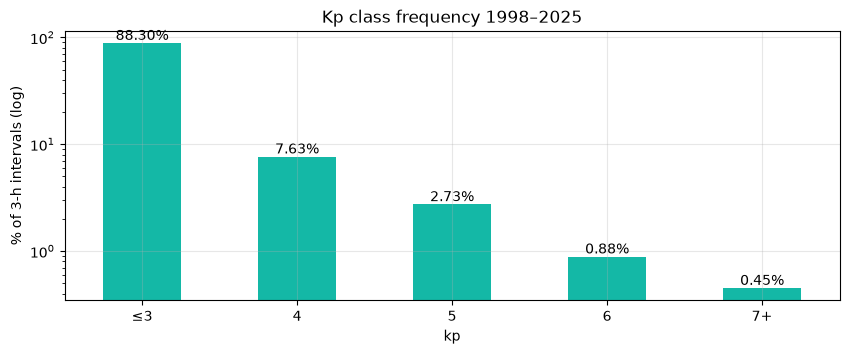

In [2]:
# A level k is reached from k- upwards (k - 1/3), matching NOAA's G-scale convention.
bins = [-0.1, 3.5, 4.5, 5.5, 6.5, 10]  # 3+ (3.33) -> "<=3", 4- (3.67) -> "4", ...
labels = ["≤3", "4", "5", "6", "7+"]
cls = pd.cut(kp.kp, bins=bins, labels=labels)
share = cls.value_counts(normalize=True).reindex(labels)

thresholds = pd.Series({f"Kp ≥ {k}": (kp.kp >= k - 0.34).mean() for k in (4, 5, 6, 7, 8)})
print("Class shares (%):")
print((share * 100).round(2).to_string())
print()
print("Exceedance (%):")
print((thresholds * 100).round(2).to_string())

ax = (share * 100).plot.bar(color="#14b8a6", rot=0)
ax.set_yscale("log")
ax.set_ylabel("% of 3-h intervals (log)")
ax.set_title("Kp class frequency 1998–2025")
for p, v in zip(ax.patches, share * 100):
    ax.annotate(f"{v:.2f}%", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom")
plt.show()

**Takeaway:** quiet conditions dominate. Kp ≥ 7 occurs in well under 1 % of intervals, so plain accuracy is useless as a metric (always predicting "quiet" is >99 % accurate). We use Brier skill score, reliability diagrams and PR-AUC, and evaluate storm periods separately.

**Threshold convention:** a value is counted as reaching level k from k− upwards (for example 5− = 4.67 counts as Kp 5), which matches the class bins above. This choice has to be fixed before modelling and documented in the model card.

## 2 · Solar cycle dependence

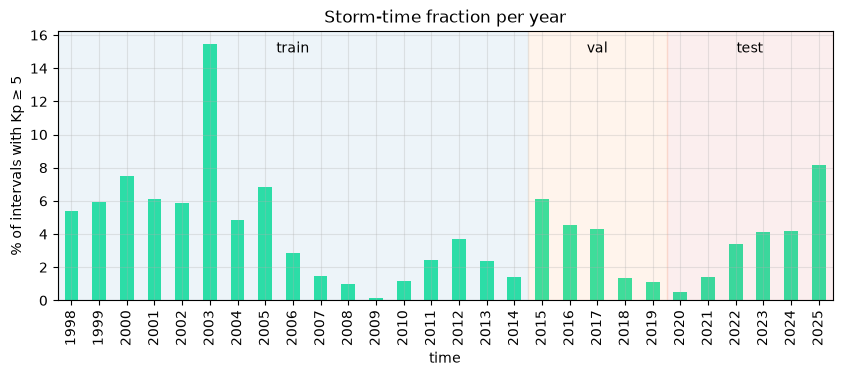

In [3]:
yearly = kp.kp.ge(5 - 0.34).groupby(kp.index.year).mean() * 100
ax = yearly.plot.bar(color="#2ee6a6", rot=90)
ax.set_ylabel("% of intervals with Kp ≥ 5")
ax.set_title("Storm-time fraction per year")
years = list(yearly.index)
for name, (a, b), c in [("train", (1998, 2014), "C0"), ("val", (2015, 2019), "C1"), ("test", (2020, 2025), "C3")]:
    i0, i1 = years.index(a), years.index(b)
    ax.axvspan(i0 - 0.5, i1 + 0.5, alpha=0.08, color=c)
    ax.text((i0 + i1) / 2, ax.get_ylim()[1] * 0.92, name, ha="center")
plt.show()

**Takeaway:** storm frequency varies by an order of magnitude across the ~11-year cycle. The test period (2020–2025) covers the rise and maximum of Cycle 25, so it is a demanding, realistic test. The validation period (2015–2019) is the declining phase and minimum of Cycle 24, which is quieter. Keep this in mind when comparing validation and test scores.

## 3 · Persistence and the 27-day recurrence

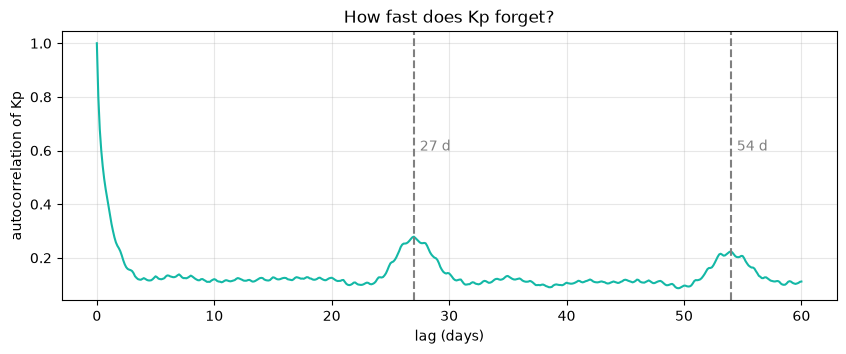

lag   3 h: r = 0.80
lag   6 h: r = 0.68
lag  12 h: r = 0.54
lag  24 h: r = 0.39
lag  72 h: r = 0.15
lag  20 d: r = 0.13
lag  27 d: r = 0.28
lag  34 d: r = 0.12
lag  54 d: r = 0.22


In [4]:
s = kp.kp.asfreq("3h")
lags = np.arange(0, 60 * 8 + 1)  # in 3-hour steps, up to 60 days
acf = np.array([s.autocorr(lag=int(l)) for l in lags])

fig, ax = plt.subplots()
ax.plot(lags / 8, acf, color="#14b8a6")
for d in (27, 54):
    ax.axvline(d, ls="--", color="grey")
    ax.text(d + 0.5, 0.6, f"{d} d", color="grey")
ax.set_xlabel("lag (days)")
ax.set_ylabel("autocorrelation of Kp")
ax.set_title("How fast does Kp forget?")
plt.show()

for h in (3, 6, 12, 24, 72):
    print(f"lag {h:>3} h: r = {s.autocorr(lag=h // 3):.2f}")
for d in (20, 27, 34, 54):
    print(f"lag {d:>3} d: r = {s.autocorr(lag=d * 8):.2f}")

**Takeaways:**
- Kp is strongly autocorrelated over a few hours, so **persistence is a strong baseline** at 1–3 h. Our model has to beat it.
- The correlation drops within about a day, which is why a few-hours model can't make a 3-night outlook.
- There are clear peaks at **27 and 54 days** (compare with the 20- and 34-day lags): coronal holes returning with the Sun's rotation. They are real but weak, which justifies a *low-confidence* weeks-ahead hint and nothing stronger.
- This autocorrelation is also why the train/val/test splits need an **embargo gap** of about 30 days.

## 4 · Does solar-wind coupling track Kp?

Newell coupling `dΦ/dt = V^(4/3) · Bt^(2/3) · sin^(8/3)(θ/2)` estimates the rate of dayside reconnection, i.e. how much solar-wind energy enters the magnetosphere.

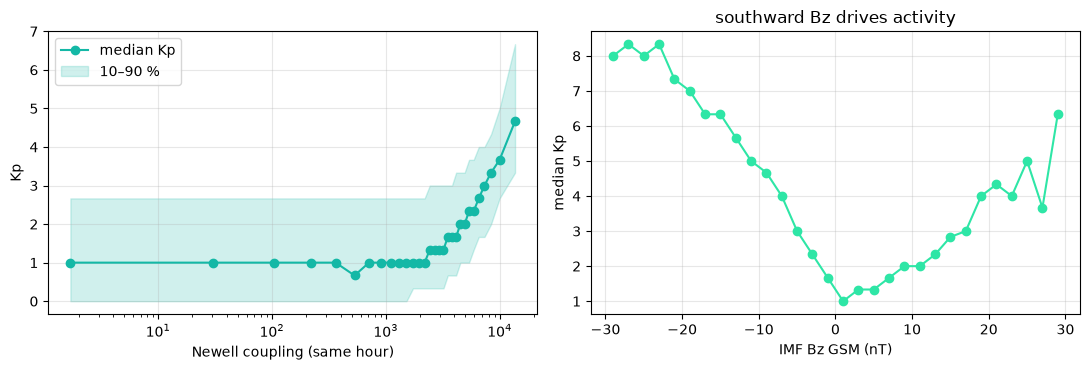

Spearman (rank) correlation with Kp:
newell    0.55
bz       -0.33


In [5]:
bt = np.hypot(hourly.by_gsm, hourly.bz_gsm)
theta = np.arctan2(hourly.by_gsm, hourly.bz_gsm)  # clock angle: 0 = northward, pi = southward
newell = hourly.speed ** (4 / 3) * bt ** (2 / 3) * np.abs(np.sin(theta / 2)) ** (8 / 3)
df = pd.DataFrame({"newell": newell, "bz": hourly.bz_gsm, "kp": hourly.kp_bin}).dropna().loc[:"2025"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
q = pd.qcut(df.newell, 30)
g = df.groupby(q, observed=True).kp
mid = df.groupby(q, observed=True).newell.median()
axes[0].plot(mid, g.median(), "o-", color="#14b8a6", label="median Kp")
axes[0].fill_between(mid, g.quantile(0.1), g.quantile(0.9), alpha=0.2, color="#14b8a6", label="10–90 %")
axes[0].set_xscale("log")
axes[0].set_xlabel("Newell coupling (same hour)")
axes[0].set_ylabel("Kp")
axes[0].legend()

b = pd.cut(df.bz, np.arange(-30, 31, 2))
gb = df.groupby(b, observed=True).kp.median()
axes[1].plot([i.mid for i in gb.index], gb, "o-", color="#2ee6a6")
axes[1].set_xlabel("IMF Bz GSM (nT)")
axes[1].set_ylabel("median Kp")
axes[1].set_title("southward Bz drives activity")
plt.tight_layout()
plt.show()

print("Spearman (rank) correlation with Kp:")
print(df[["newell", "bz"]].rank().corrwith(df.kp.rank()).round(2).to_string())

**Takeaways:**
- Kp rises steadily with Newell coupling, and **southward Bz (negative) drives activity** while northward Bz barely does. This confirms the physics behind the feature set.
- The 10–90 % band is wide: the same hourly coupling can give quite different Kp. Two reasons are that the magnetosphere *integrates* its input over hours (hence the rolling-window features) and that Kp is a 3-hour index. This spread is the reason for predicting probabilities instead of a single number.

## 5 · Data gaps

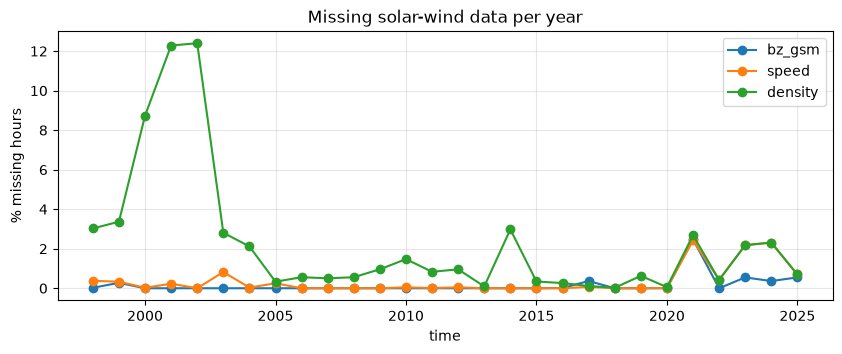

time     1998  1999  2000  2001  2002  2003  2004  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025
bz_gsm    0.0   0.3   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.4   0.0   0.0   0.0   2.5   0.0   0.5   0.4   0.5
speed     0.4   0.3   0.0   0.2   0.0   0.8   0.0   0.3   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.1   0.0   0.0   0.0   2.4   0.4   2.2   2.3   0.7
density   3.0   3.4   8.7  12.3  12.4   2.8   2.1   0.3   0.6   0.5   0.6   1.0   1.5   0.8   1.0   0.1   3.0   0.3   0.3   0.1   0.0   0.6   0.1   2.7   0.4   2.2   2.3   0.7


In [6]:
h = hourly.loc[:"2025"]
gaps = h[["bz_gsm", "speed", "density"]].isna().groupby(h.index.year).mean() * 100
ax = gaps.plot(marker="o")
ax.set_ylabel("% missing hours")
ax.set_title("Missing solar-wind data per year")
plt.show()
print(gaps.round(1).T.to_string())

**Takeaway:** gaps are small overall, but plasma (density/speed) is missing more often than the magnetic field. LightGBM handles NaN natively, so no imputation is needed. The same will apply to live DSCOVR/ACE outages in production.

## 6 · Case study: the May 2024 "Gannon" storm

The strongest geomagnetic storm in over 20 years (Kp 9, aurora seen across all of Germany and far into southern Europe). It was caused by a series of CMEs from sunspot region AR 13664. All quantities are OMNI hourly values, already shifted to the bow-shock nose, so the time axis shows when the solar wind *reached Earth*, not when it passed L1.

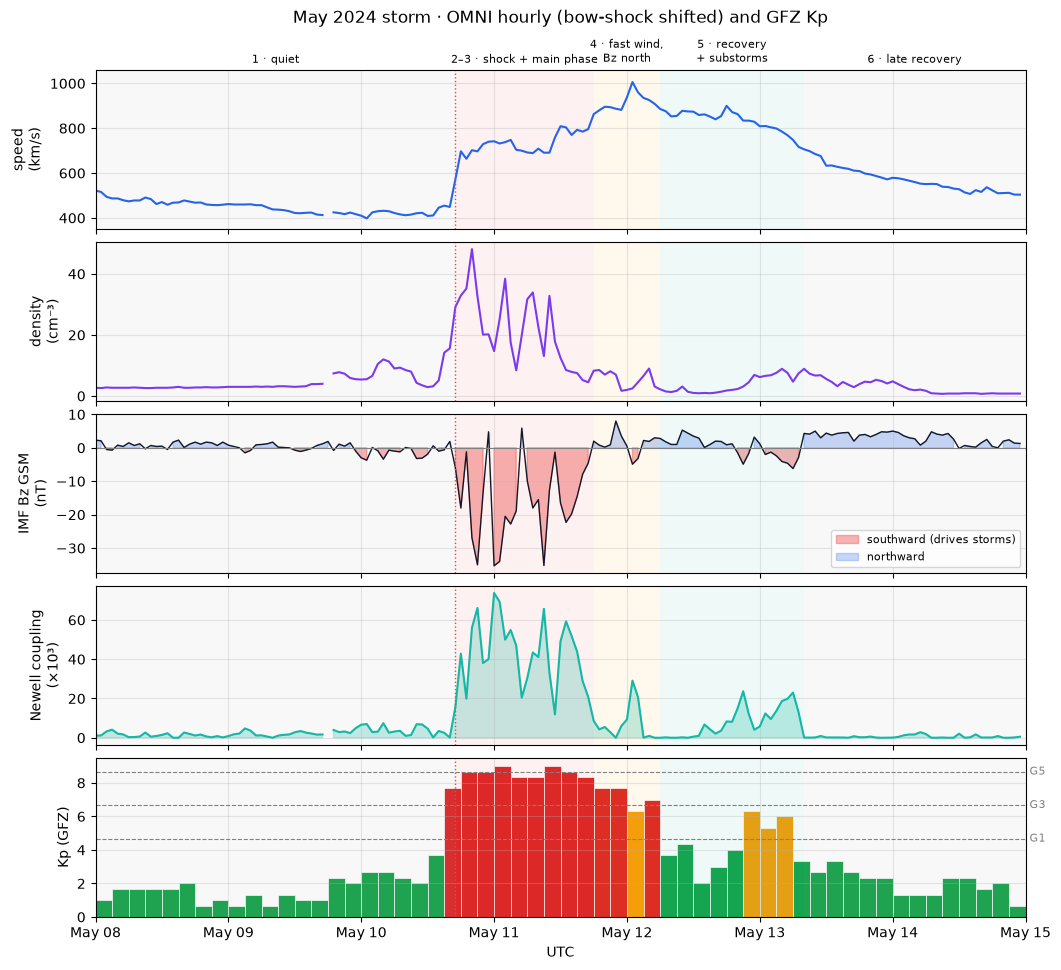

In [7]:
storm =hourly.loc["2024-05-08":"2024-05-14"].copy()
bt_s = np.hypot(storm.by_gsm, storm.bz_gsm)
theta_s = np.arctan2(storm.by_gsm, storm.bz_gsm)
storm["newell"] = storm.speed ** (4 / 3) * bt_s ** (2 / 3) * np.abs(np.sin(theta_s / 2)) ** (8 / 3)
kp_storm = pd.read_parquet(PROCESSED_DIR / "kp_3h.parquet").loc["2024-05-08":"2024-05-14", "kp"]

T = lambda s: pd.Timestamp(s, tz="UTC")
phases = [  # (start, end, label, colour)
    (T("2024-05-08"), T("2024-05-10 17:00"), "1 · quiet", "#9ca3af"),
    (T("2024-05-10 17:00"), T("2024-05-11 18:00"), "2–3 · shock + main phase", "#ef4444"),
    (T("2024-05-11 18:00"), T("2024-05-12 06:00"), "4 · fast wind,\nBz north", "#f59e0b"),
    (T("2024-05-12 06:00"), T("2024-05-13 08:00"), "5 · recovery\n+ substorms", "#14b8a6"),
    (T("2024-05-13 08:00"), T("2024-05-15"), "6 · late recovery", "#9ca3af"),
]

fig, axes = plt.subplots(5, 1, figsize=(12, 11), sharex=True, gridspec_kw={"hspace": 0.08})
ax_v, ax_n, ax_bz, ax_c, ax_kp = axes

ax_v.plot(storm.index, storm.speed, color="#2563eb")
ax_v.set_ylabel("speed\n(km/s)")

ax_n.plot(storm.index, storm.density, color="#7c3aed")
ax_n.set_ylabel("density\n(cm⁻³)")

ax_bz.plot(storm.index, storm.bz_gsm, color="#111827", lw=1)
ax_bz.fill_between(storm.index, storm.bz_gsm, 0, where=storm.bz_gsm < 0, color="#ef4444", alpha=0.4, label="southward (drives storms)")
ax_bz.fill_between(storm.index, storm.bz_gsm, 0, where=storm.bz_gsm > 0, color="#2563eb", alpha=0.25, label="northward")
ax_bz.axhline(0, color="grey", lw=0.8)
ax_bz.set_ylabel("IMF Bz GSM\n(nT)")
ax_bz.legend(loc="lower right", fontsize=8)

ax_c.plot(storm.index, storm.newell / 1e3, color="#14b8a6")
ax_c.fill_between(storm.index, storm.newell / 1e3, color="#14b8a6", alpha=0.25)
ax_c.set_ylabel("Newell coupling\n(×10³)")

kp_colors = ["#16a34a" if k < 4.67 else "#f59e0b" if k < 6.67 else "#dc2626" for k in kp_storm]
ax_kp.bar(kp_storm.index, kp_storm, width=pd.Timedelta("3h"), align="edge", color=kp_colors, edgecolor="white", lw=0.5)
for level, name in [(5, "G1"), (7, "G3"), (9, "G5")]:
    ax_kp.axhline(level - 1 / 3, color="grey", ls="--", lw=0.8)
    ax_kp.text(T("2024-05-15"), level - 1 / 3, f" {name}", va="center", fontsize=8, color="grey")
ax_kp.set_ylim(0, 9.5)
ax_kp.set_ylabel("Kp (GFZ)")

for ax in axes:
    for start, end, _, colour in phases:
        ax.axvspan(start, end, color=colour, alpha=0.07, lw=0)
    ax.axvline(T("2024-05-10 17:00"), color="#ef4444", ls=":", lw=1)
for start, end, label, _ in phases:
    ax_v.text(start + (end - start) / 2, 1080, label, ha="center", va="bottom", fontsize=8)
ax_v.set_ylim(350, 1060)
ax_v.set_title("May 2024 storm · OMNI hourly (bow-shock shifted) and GFZ Kp", pad=34)

ax_kp.set_xlim(T("2024-05-08"), T("2024-05-15"))
ax_kp.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %d"))
ax_kp.set_xlabel("UTC")

from aurora.config import ROOT

(ROOT / "reports").mkdir(exist_ok=True)
fig.savefig(ROOT / "reports" / "may2024_storm.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Numbers behind the phase descriptions below
def summary(a, b):
    s = storm.loc[a:b]
    k = kp_storm.loc[a:b]
    return pd.Series({
        "speed max": s.speed.max(), "density max": s.density.max(), "Bz min": s.bz_gsm.min(),
        "Newell median (×10³)": s.newell.median() / 1e3, "Kp max": k.max(), "Dst min": s.dst.min(),
    })

table = pd.DataFrame({label.replace("\n", " "): summary(a, b - pd.Timedelta("1h")) for a, b, label, _ in phases}).T
table.round(1)

,speed max,density max,Bz min,Newell median (×10³),Kp max,Dst min
1 · quiet,522.0,15.6,-3.7,1.9,7.7,-1.0
2–3 · shock + main phase,809.0,48.1,-35.3,43.4,9.0,-406.0
"4 · fast wind, Bz north",1006.0,9.0,-4.9,4.9,7.7,-203.0
5 · recovery + substorms,900.0,8.9,-6.2,6.3,6.3,-132.0
6 · late recovery,706.0,8.9,-0.2,0.2,3.3,-63.0


### What happens in each phase

**1 · Quiet (May 8 to May 10, 17 UT).** Slow solar wind (≈ 400–520 km/s), low density, a weak field of only 2–7 nT with Bz flickering around zero. Newell coupling stays at a few thousand units and Kp is 0–3, briefly 4− on May 10. Small density and |B| bumps on May 9–10 are weak forerunners with no real effect, because Bz never turns strongly southward.

**2 · Shock arrival (≈ 17 UT on May 10).** The leading shock of the CME series reaches Earth. Within two hours speed jumps from ≈ 450 to ≈ 700 km/s, density roughly doubles to ≈ 30 cm⁻³, |B| goes from ≈ 3 to over 30 nT and dynamic pressure rises from ≈ 5 to ≈ 30 nPa (about 25× the quiet level). The pressure pulse squeezes the magnetosphere, so Dst briefly turns *positive* (+66 nT, the "sudden commencement"). Note that the GFZ Kp of the **15–18 UT interval is already 7.67**: one disturbed hour is enough to lift a whole 3-hour Kp value. This is exactly why our target is "the Kp interval *containing* t + h" and why the model must treat Kp as a 3-hour quantity.

**3 · Main phase (May 10, 18 UT to May 11, ≈ 18 UT).** The magnetic cloud of the CMEs brings |B| up to ≈ 69 nT and **Bz down to −35 nT, staying southward for most of a day**. Combined with ≈ 690–810 km/s, Newell coupling reaches 40,000–74,000, which is **20–30× the quiet level**. This is dayside reconnection at an extreme rate: energy pours into the magnetosphere, the ring current builds up (Dst falls to −406 nT at 02 UT on May 11) and the auroral oval expands far south. Kp reaches **9 (the maximum)** twice (May 11, 00–03 and 09–12 UT) and stays at 8− or above for about 33 hours. Short northward turnings (for example +4.8 nT at 23 UT, +5.9 nT at 05 UT) cause sharp *dips* in coupling, but Kp barely drops. The magnetosphere integrates its input over hours, which motivates the rolling-window features.

**4 · Fast wind with northward Bz (May 11, 18 UT to May 12, ≈ 06 UT).** This phase holds the key lesson. **The fastest wind of the whole event arrives now, up to ≈ 1000 km/s**, but Bz has turned northward. Newell coupling collapses to a small fraction of the main-phase level. Kp does *not* drop instantly: it stays at 6–8 for these hours, because the magnetosphere is still releasing energy stored during the main phase, and because of one short southward turn (−4.9 nT at 01 UT May 12, at ≈ 1000 km/s, clearly visible as a coupling spike). Once Bz stays northward, Kp falls to **3.7 at 06–09 UT on May 12, with the wind still at ≈ 880 km/s**. Speed alone does not drive storms: without southward Bz, reconnection on the dayside largely stops. A model that used speed alone would predict the peak of the storm here. Coupling functions that include the clock angle get this right, and Kp lags (past Kp as features) capture the stored energy that keeps Kp elevated for a few hours.

**5 · Recovery with substorms (May 12, 06 UT to May 13, ≈ 08 UT).** The wind is still fast (≈ 750–900 km/s) but thin, and |B| is back to ≈ 4–10 nT. Whenever Bz dips to −2 … −6 nT, the high speed still produces substantial coupling, and **Kp pops back up to 6–6.3** (May 12, 21–24 UT and May 13, 03–06 UT). For Germany this matters: Kp 6 can still mean aurora on the northern horizon in northern Germany, two days after the "main event". Dst recovers slowly from ≈ −130 to −65 nT as the ring current decays.

**6 · Late recovery (May 13, 08 UT onwards).** Bz stays northward and speed slowly declines (≈ 700 → 500 km/s). Kp falls back to 1–3, while Dst is still around −40 to −60 nT. The ring current takes days to fully decay, much longer than Kp takes to drop.

### Lessons for the model
| Observation | Consequence |
|---|---|
| Kp follows **southward Bz × speed**, not speed alone (phase 4) | use coupling functions (Newell, E_y = −V·Bz) as core features, not raw speed |
| Kp stays elevated for a few hours after coupling drops (phase 4) | include past Kp (last *completed* 3-h interval) as features |
| Brief northward turnings don't reset Kp (phase 3) | rolling means/min of Bz and coupling over 1–6 h; hours-since-southward |
| A single disturbed hour lifts a whole 3-hour Kp value (phase 2) | define targets on the 3-hour Kp grid; evaluate on that grid |
| Kp 6 can recur during recovery (phase 5) | keep predicting from current solar wind; don't assume "storm over" |
| One plasma hour missing on May 9 | NaN-tolerant model; don't drop rows |

## Summary for modelling
| Finding | Decision |
|---|---|
| Kp ≥ 7 < 1 % of intervals | probabilistic output, Brier/BSS + PR-AUC, separate storm evaluation |
| Strong cycle dependence | test on 2020–2025 (Cycle 25), report per-period scores |
| High short-lag autocorrelation | persistence baseline; ~30-day embargo between splits |
| 27/54-day peaks | weeks-ahead hint from recurrence, shown as low confidence |
| Kp tracks Newell coupling and southward Bz | coupling + rolling windows as core features |
| Small, plasma-heavy gaps | no imputation; rely on LightGBM NaN handling |
| May 2024: fastest wind but low Kp when Bz was northward | clock-angle-aware coupling features, not raw speed |